# 2.1
Da es sich um ein unüberwachtes Lernmodell (K-Means Clustering) handelt, gibt es kein vordefiniertes Ziel-Feld. Das Ziel ist die Identifizierung von Clustern bzw. "Vibes" basierend auf den Audio-Merkmalen. Das Modell generiert somit eine neue kategoriale Variable (Cluster-ID), die Tracks mit ähnlichen klanglichen Eigenschaften gruppiert.

# 2.2
asierend auf den vorherigen Schritten und der Auswahl für dein Projekt haben wir die folgenden neun numerischen Audio-Features für die statistische Analyse (Aufgabe 2.2) bestimmt:
- danceability: Beschreibt, wie geeignet ein Track zum Tanzen ist (0.0 bis 1.0).
- energy: Ein Maß für die Intensität und Aktivität eines Songs (0.0 bis 1.0).
- loudness: Die durchschnittliche Lautstärke des Tracks in Dezibel (dB).
- speechiness: Erfasst die Präsenz von gesprochenen Worten im Track.
- acousticness: Die Wahrscheinlichkeit, dass der Song rein akustisch (ohne elektrische Instrumente) ist.
- instrumentalness: Die Wahrscheinlichkeit, dass ein Track keine Gesangsstimmen enthält.
- liveness: Erkennt die Anwesenheit eines Publikums (Live-Aufnahme).
- valence: Beschreibt die musikalische Positivität/Stimmung (hoch = fröhlich, niedrig = traurig).tempo: Die Geschwindigkeit des Tracks in Beats per Minute (BPM).

In [ ]:
# Installation der notwendigen Bibliotheken
!pip install pandas seaborn matplotlib scikit-learn

Statistische Übersicht:
       danceability        energy      loudness   speechiness  acousticness  \
count  81344.000000  81344.000000  81344.000000  81344.000000  81344.000000   
mean       0.559275      0.635025     -8.593940      0.088992      0.329670   
std        0.177746      0.258639      5.304765      0.116628      0.339961   
min        0.000000      0.000000    -49.531000      0.000000      0.000000   
25%        0.446000      0.455000    -10.451250      0.036100      0.015900   
50%        0.573000      0.678000     -7.262000      0.049100      0.190000   
75%        0.690000      0.857000     -5.140000      0.087000      0.629000   
max        0.985000      1.000000      4.532000      0.965000      0.996000   

       instrumentalness      liveness       valence         tempo  
count      81344.000000  81344.000000  81344.000000  81344.000000  
mean           0.184731      0.219721      0.463280    122.145034  
std            0.331591      0.198271      0.263383     30.1

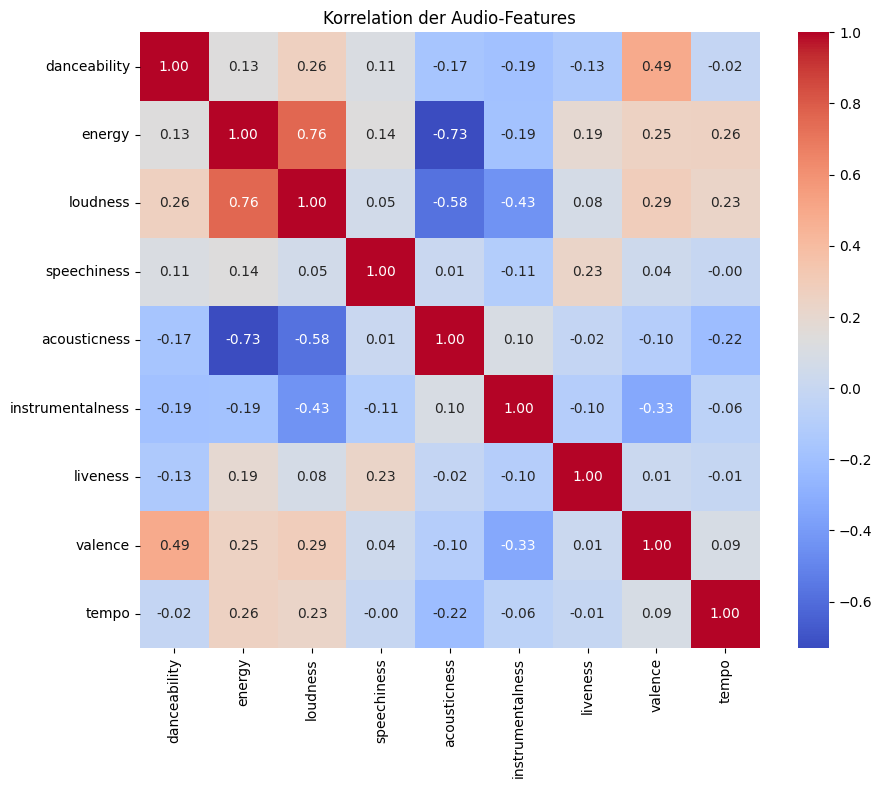

Daten erfolgreich skaliert und bereit für das Clustering.


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Daten laden (Stelle sicher, dass die CSV im selben Ordner liegt)
df = pd.read_csv('dataset.csv') 

# 2. Relevante Felder für das Clustering wählen (Aufgabe 2.1)
# Da wir K-Means nutzen, ist unser "Ziel" die Cluster-Zugehörigkeit.
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# Bereinigung: Duplikate und leere Zeilen entfernen
df_clean = df.drop_duplicates(subset=['track_name', 'artists']).dropna(subset=features)

# Aufgabe 2.2: Statistische Informationen (Median, Std, etc.)
# Diese Ausgabe kopierst du als Tabelle/Text in dein Notebook
print("Statistische Übersicht:")
print(df_clean[features].describe())

# Aufgabe 2.3: Grafik (Korrelations-Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korrelation der Audio-Features")
plt.show()

# Aufgabe 2.4: Skalierung (StandardScaler)
# Begründung: K-Means basiert auf euklidischer Distanz; ohne Skalierung 
# würde das 'Tempo' (hohe Werte) die 'Danceability' (0-1) dominieren.
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean[features]), columns=features)

print("Daten erfolgreich skaliert und bereit für das Clustering.")

# 2.4
Für dieses Modell ist eine Standardisierung mittels StandardScaler zwingend erforderlich. K-Means basiert auf der Berechnung der euklidischen Distanz. Ohne Skalierung würden Merkmale mit großen Wertebereichen, wie das "Tempo" (BPM), die Berechnung dominieren und kleinere, aber wichtige Merkmale wie "Danceability" (0.0 bis 1.0) bedeutungslos machen. Durch die Skalierung wird sichergestellt, dass jedes klangliche Attribut mit der gleichen Gewichtung in die Cluster-Bildung einfließt, um mathematische Konsistenz zu gewährleisten.